In [1]:
import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath("../"))
# KMP_DUPLICATE_LIB_OK=TRUE

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.vae_model import VAESmall, VAEMedium, VAELarge, BetaVAE, VAEPlus
import numpy as np
from tqdm import tqdm
from src.data_loading_well import load_data_by_well

def load_model_and_cfg(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    cfg = OmegaConf.create(checkpoint["config"])
    cfg.data.train_path = "D:/BBBC021/BBBC021_dataset_cleaned_maxnorm_68.h5"
    cfg.data.metadata_path = "../data/raw/metadata_dataset.h5"

    # Initialize model based on configuration
    name = cfg.model.name
    if name in ("VAESmall"):
        model = VAESmall(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAEMedium"):
        model = VAEMedium(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("VAELarge"):
        model = VAELarge(cfg.model.input_channels, cfg.model.latent_dim)
    elif name in ("Beta_VAE"):
        model = BetaVAE(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta)
    elif name in ("VAE+"):
        model = VAEPlus(cfg.model.input_channels, cfg.model.latent_dim, cfg.model.beta, cfg.model.adv_schedule_slope)

    # Load model state dict
    model.cfg = cfg
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [3]:
model_large = load_model_and_cfg("../experiments/models/LatentTest2/large_64.pth")
model_plus = load_model_and_cfg("../experiments/models/VAEPlus/large_32_32_32_64_2.pth")

cfg = model_plus.cfg
val_loader = load_data_by_well(cfg, split="test")

Total wells Train: 770, Val: 96, Test: 96
Total images in test: 46458 (9.66% of total)


In [4]:
# --- Gradient Sensitivity Analysis ---
def run_gradient_sensitivity(model, loader, n_samples=1000, batch_size=100):
    print(">> Computing gradient sensitivity")
    device = next(model.parameters()).device
    D = model.fc_mu.out_features
    sens = torch.zeros(D, device=device)
    model.decoder.eval()

    for _ in range(n_samples // batch_size):
        z = torch.randn(batch_size, D, device=device, requires_grad=True)
        recon = model.decode(z)
        scores = recon.view(batch_size, -1).pow(2).sum(dim=1)
        grads = torch.autograd.grad(scores.sum(), z)[0]
        sens += grads.abs().sum(dim=0)

    sens = sens / n_samples
    sens_cpu = sens.cpu().numpy()
    sorted_idx = np.argsort(sens_cpu)[::-1]
    return sorted_idx

# --- Heatmap Computation for Single Latent Dimension ---
def compute_latent_effect_heatmap(model, x, mu, z_idx, delta_range=(-3, 3), steps=5):
    device = x.device
    base_recon = model.decode(mu).detach()
    delta_vals = torch.linspace(*delta_range, steps).to(device)
    diffs = []

    for delta in delta_vals:
        z_ = mu.clone()
        z_[:, z_idx] += delta
        recon = model.decode(z_)
        diff = recon - base_recon
        diffs.append(diff[0].cpu())

    avg_diff = torch.stack(diffs).mean(dim=0)
    heatmap = avg_diff.mean(dim=0)  # average over channels
    return heatmap  # [H, W]

def compute_avg_latent_heatmap(model, loader, top_dims, n_samples=100, steps=5):
    model.eval()
    device = next(model.parameters()).device
    heatmaps = [torch.zeros(68, 68) for _ in top_dims]  # adjust H, W as needed
    count = 0

    for x_batch, _ in loader:
        x_batch = x_batch.to(device)
        mu, logvar = model.encode(x_batch)

        for b in range(min(x_batch.size(0), n_samples - count)):
            x = x_batch[b:b+1]
            mu_i = mu[b:b+1]
            for i, z_idx in enumerate(top_dims):
                h = compute_latent_effect_heatmap(model, x, mu_i, z_idx, steps=steps)
                heatmaps[i] += h
            count += 1
            if count >= n_samples:
                break
        if count >= n_samples:
            break

    return [h / count for h in heatmaps]

In [5]:
import torch
import numpy as np

def run_gradient_sensitivity(model, loader, n_samples=1000, batch_size=100):
    print(">> Computing gradient sensitivity (memory‐optimized)")
    device = next(model.parameters()).device
    D = model.fc_mu.out_features
    model.decoder.eval()
    total_sens = torch.zeros(D, device=device)
    num_batches = n_samples // batch_size

    torch.manual_seed(42)

    for _ in range(num_batches):
        z = torch.randn(batch_size, D, device=device, requires_grad=True)
        recon = model.decode(z)
        scores = (recon.view(batch_size, -1).pow(2).sum(dim=1)).sum()
        grads = torch.autograd.grad(scores, z, retain_graph=False)[0]
        total_sens += grads.abs().sum(dim=0)
        del z, recon, scores, grads
        torch.cuda.empty_cache()

    avg_sens = total_sens / float(n_samples)
    sens_cpu = avg_sens.cpu().numpy()
    sorted_idx = np.argsort(sens_cpu)[::-1]
    return sorted_idx

def compute_latent_effect_heatmap(model, x, mu, z_idx, delta_range=(-3, 3), steps=5):
    device = x.device
    with torch.no_grad():
        base_recon = model.decode(mu)
        base_recon_det = base_recon.detach()
    C, H, W = base_recon_det.shape[1:]
    running_map = torch.zeros((H, W), device=device)
    delta_vals = torch.linspace(delta_range[0], delta_range[1], steps, device=device)

    for delta in delta_vals:
        z_modified = mu.clone()
        z_modified[0, z_idx] += delta
        with torch.no_grad():
            recon_mod = model.decode(z_modified)
            diff_map =  (recon_mod[0] - base_recon_det[0]).mean(dim=0)
        running_map += diff_map
        del z_modified, recon_mod, diff_map
        torch.cuda.empty_cache()

    avg_map = running_map / float(steps)
    return avg_map.cpu()

def compute_avg_latent_heatmap(model, loader, top_dims, n_samples=100, steps=5):
    # seed
    torch.manual_seed(42)
    model.eval()
    device = next(model.parameters()).device
    num_dims = len(top_dims)
    H, W = 68, 68
    heatmaps_acc = torch.zeros((num_dims, H, W), device=device)
    dataset = loader.dataset
    total = len(dataset)
    if n_samples > total:
        n_samples = total
    perm = torch.randperm(total)[:n_samples]
    count = 0
    for idx_tensor in perm:
        idx = int(idx_tensor)
        x, _ = dataset[idx]
        x = x.unsqueeze(0).to(device)
        with torch.no_grad():
            mu_i, logvar = model.encode(x)
        for dim_idx, z_idx in enumerate(top_dims):
            single_map = compute_latent_effect_heatmap(
                model,
                x,
                mu_i,
                z_idx,
                delta_range=(-3, 3),
                steps=steps,
            )
            heatmaps_acc[dim_idx] += single_map.to(device)
        count += 1
    heatmaps_acc /= float(count)
    heatmaps_cpu = [heatmaps_acc[i].cpu().numpy() for i in range(num_dims)]

    # Find the maximum absolute value across all heatmaps
    # all_vals = np.concatenate([h.flatten() for h in heatmaps_cpu])
    # abs_max = np.max(np.abs(all_vals))  
    abs_maxes = [np.max(np.abs(h)) for h in heatmaps_cpu]

    return heatmaps_cpu, abs_maxes

In [6]:
# Get top 50 sensitive latent dims
top50_dims_large = run_gradient_sensitivity(model_large, val_loader, n_samples=1000)[:50]
top50_dims_plus = run_gradient_sensitivity(model_plus, val_loader, n_samples=1000)[:50]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_large.to(device)
model_plus.to(device)

>> Computing gradient sensitivity (memory‐optimized)
>> Computing gradient sensitivity (memory‐optimized)


VAEPlus(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6400, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=6400, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=6400, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(256, 5, 5))
    (1): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (2): LeakyReLU(negative_slope=0.01)
    (3): ConvTranspose2d(128, 64, kernel_size=(

In [7]:
from matplotlib.colors import LinearSegmentedColormap
white_red = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

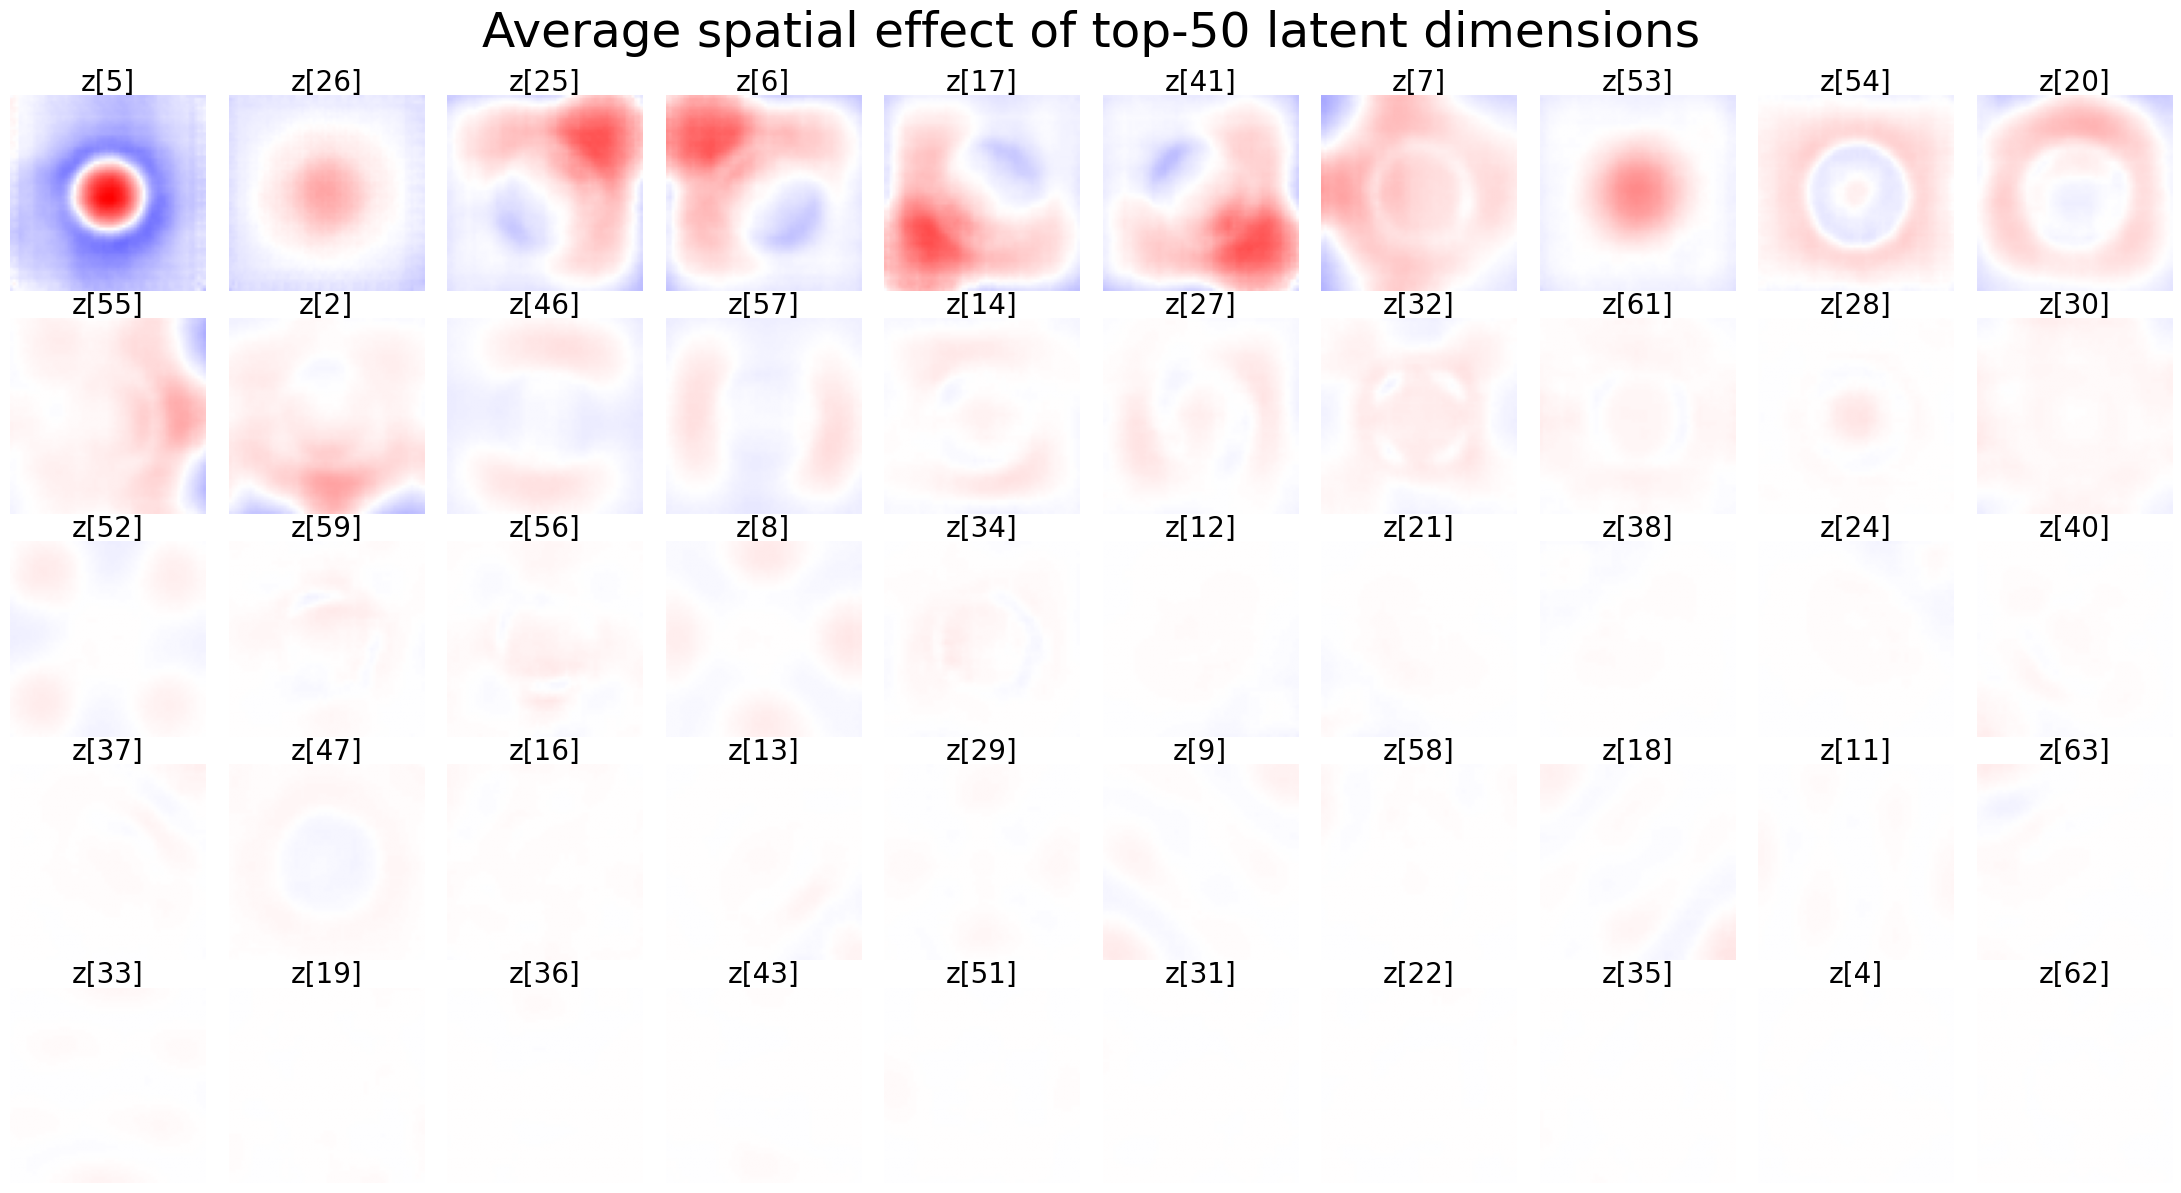

In [51]:
# Compute average heatmaps for top 50 latent dimensions
avg_heatmaps, abs_maxes = compute_avg_latent_heatmap(model_large, val_loader, top50_dims_large, n_samples=500)
# Plot average heatmaps in 5×10 grid
fig, axs = plt.subplots(5, 10, figsize=(22, 12))
for i, ax in enumerate(axs.flatten()):
    im = ax.imshow(avg_heatmaps[i], cmap='bwr', vmin=-abs_maxes[0], vmax=abs_maxes[0])
    ax.set_title(f"z[{top50_dims_large[i]}]", fontsize=20, y=0.98)
    ax.axis('off')
fig.suptitle("Average spatial effect of top-50 latent dimensions", fontsize=35, y=0.99)
# plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()

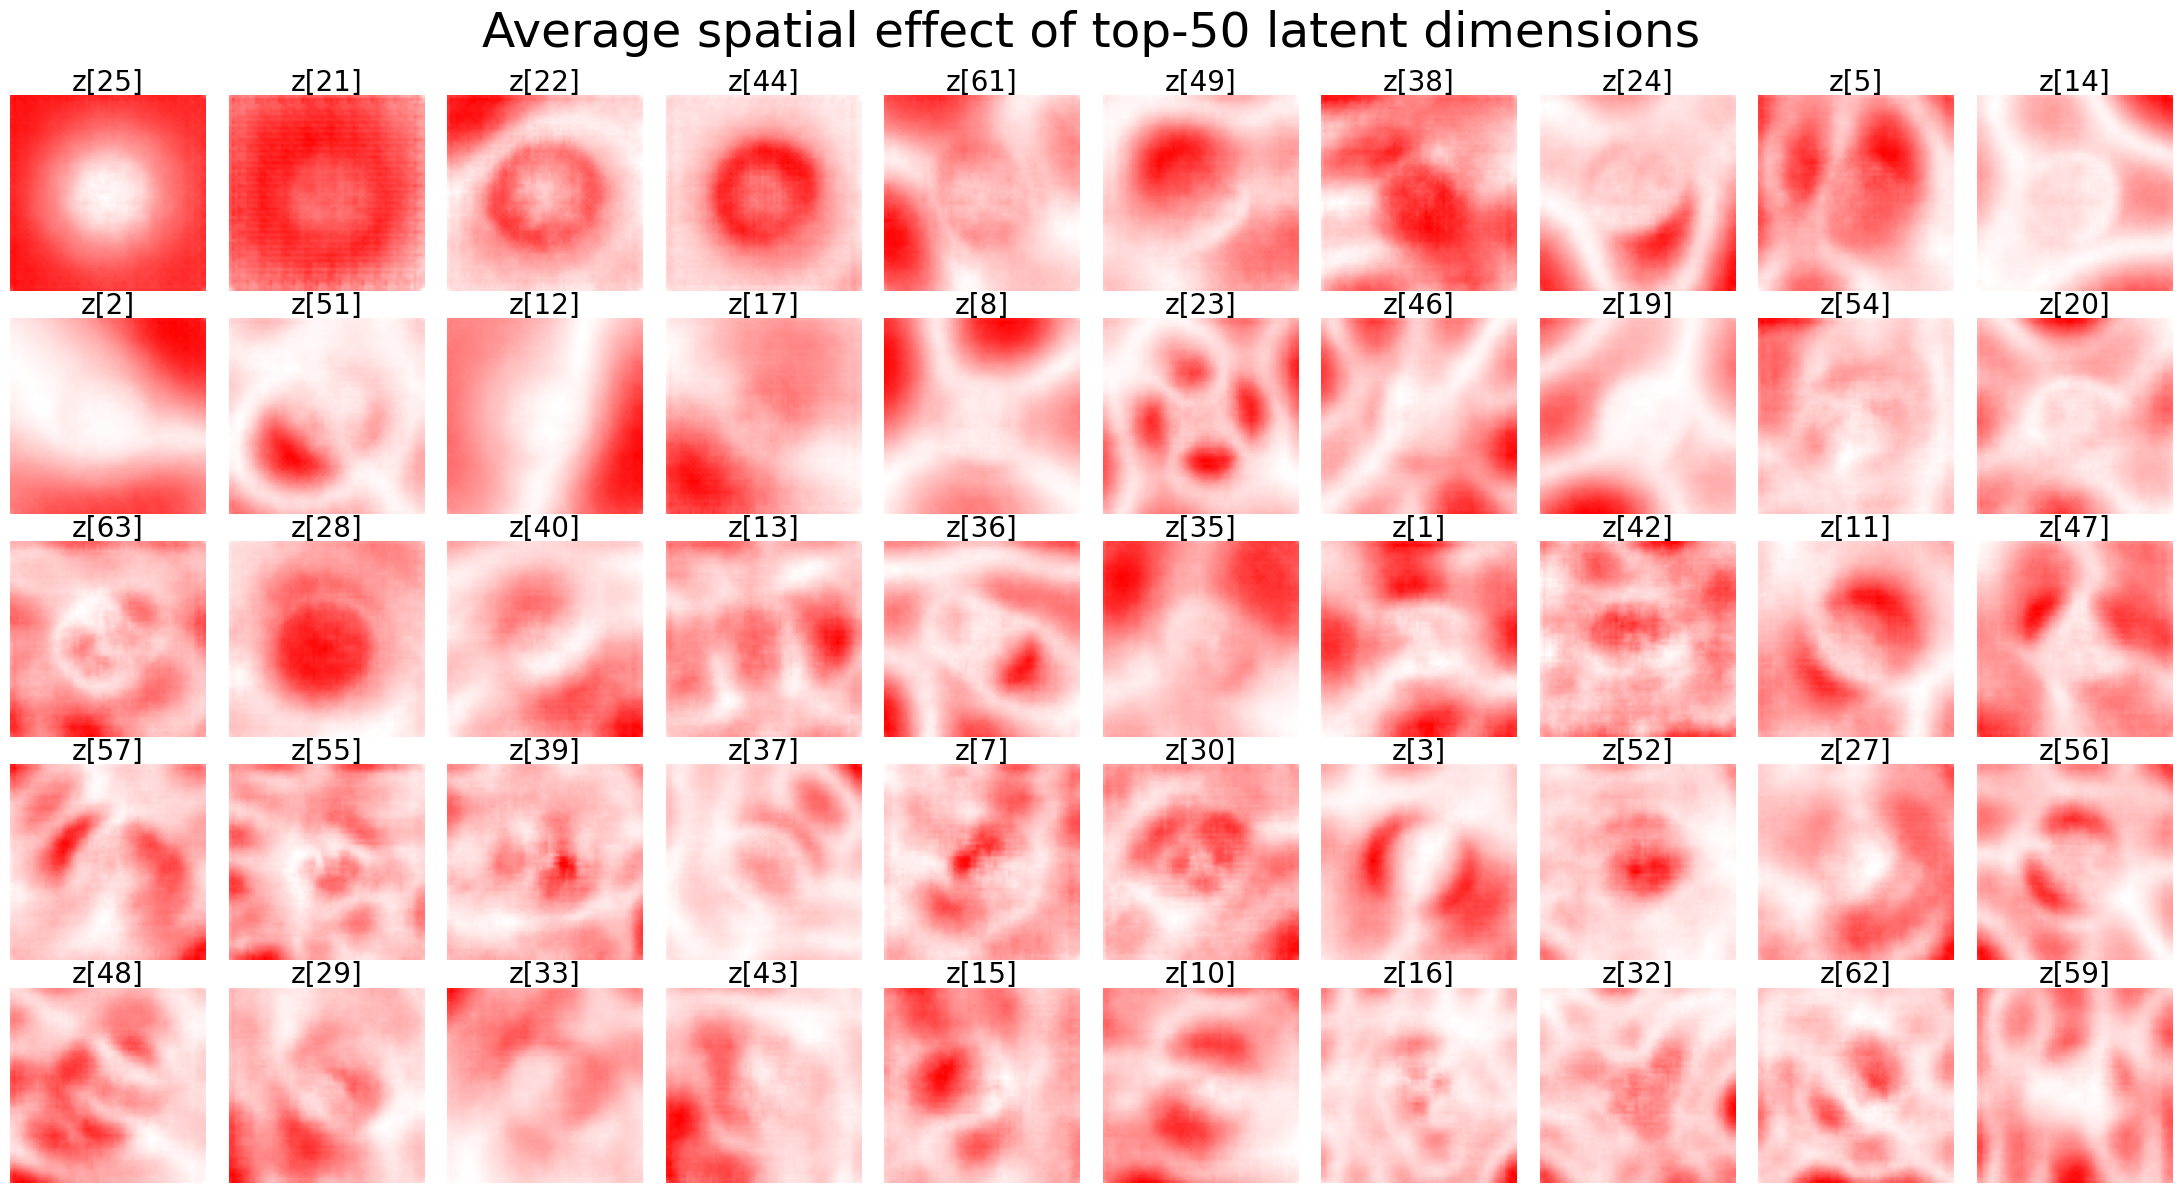

In [33]:
# Compute average heatmaps for top 50 latent dimensions
avg_heatmaps = compute_avg_latent_heatmap(model_plus, val_loader, top50_dims_plus, n_samples=500)
# Plot average heatmaps in 5×10 grid
fig, axs = plt.subplots(5, 10, figsize=(22, 12))
for i, ax in enumerate(axs.flatten()):
    im = ax.imshow(avg_heatmaps[i], cmap=white_red)
    ax.set_title(f"z[{top50_dims_plus[i]}]", fontsize=20, y=0.98)
    ax.axis('off')
fig.suptitle("Average spatial effect of top-50 latent dimensions", fontsize=35, y=0.99)
plt.tight_layout()
plt.show()

In [34]:
delta_values = torch.linspace(-3, 3, steps=9).tolist()
steps = len(delta_values)
topN = 10

def compute_latent_traversal_images(model, z, dim_idx, delta_values):
    imgs = []
    device = z.device
    with torch.no_grad():
        for delta in delta_values:
            z_ = z.clone()
            z_[:, dim_idx] += delta
            recon = model.decode(z_).detach().cpu()
            imgs.append(recon[0])  # [C, H, W]
    return imgs

def compute_latent_traversals_and_heatmaps(model, x, z, top_dims, delta_values):
    original_recon = model.decode(z).detach().cpu()
    traversal_rows = []
    diffmaps = []

    for dim in top_dims:
        imgs = compute_latent_traversal_images(model, z, dim, delta_values)
        traversal_rows.append(imgs)

        diffmap = compute_latent_effect_heatmap(
            model, x, z, dim, delta_range=(min(delta_values), max(delta_values)), steps=len(delta_values)
        )
        diffmaps.append(diffmap)

    return traversal_rows, diffmaps, original_recon

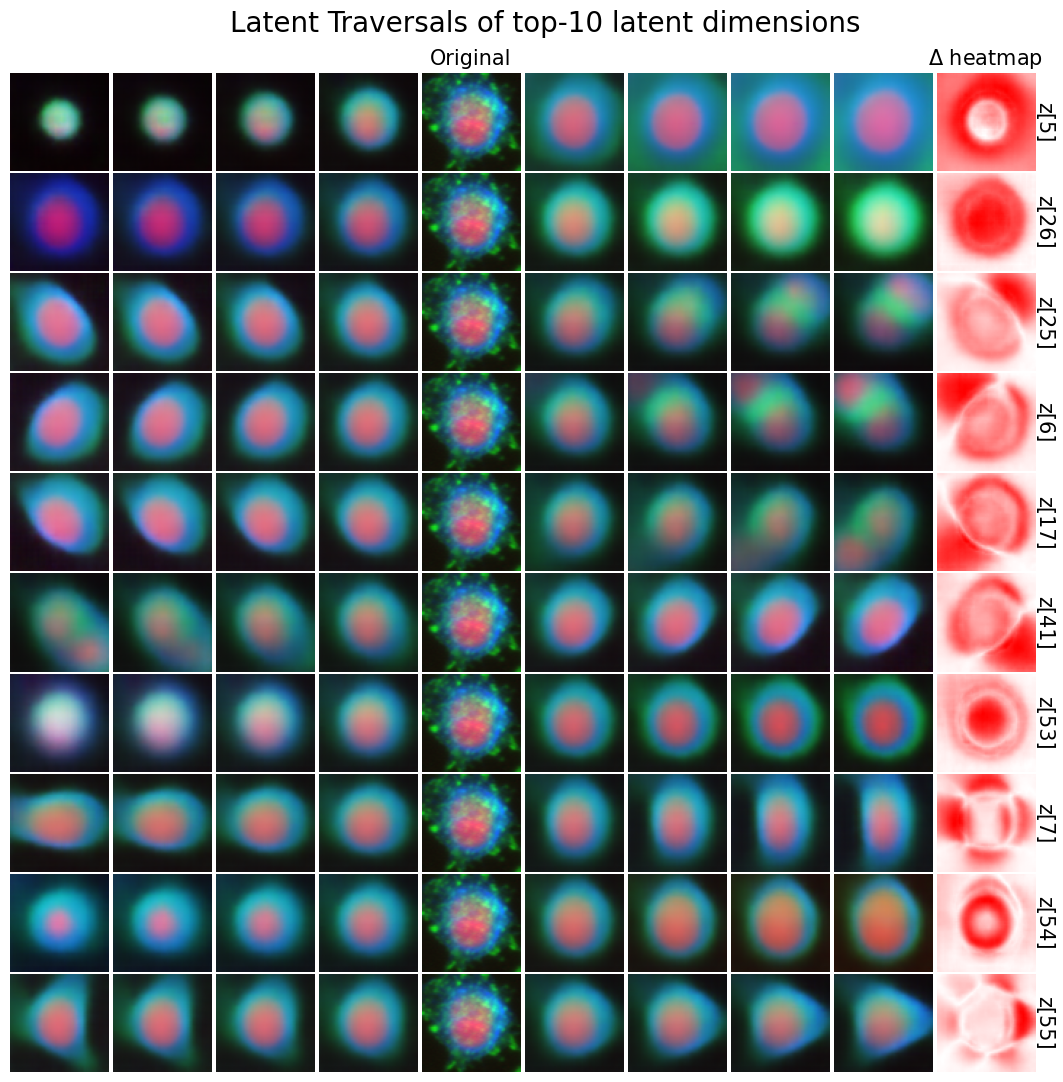

In [35]:
# --- Main execution ---
top10_dims_large = top50_dims_large[:topN]
idx = 200

dataset = val_loader.dataset
x, _ = dataset[idx]
x = x.unsqueeze(0).to(device)

with torch.no_grad():
    mu, logvar = model_large.encode(x)
    z = model_large.reparameterize(mu, logvar)

rows, diffmaps, original_recon = compute_latent_traversals_and_heatmaps(model_large, x, z, top10_dims_large, delta_values)

fig, axs = plt.subplots(topN, steps + 1, figsize=(11, 11))

for i in range(topN):
    for j in range(steps):
        img = rows[i][j].permute(1, 2, 0).numpy()
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
    axs[i, steps // 2].imshow(x[0].permute(1, 2, 0).cpu().numpy())
    axs[i, -1].imshow(diffmaps[i], cmap=white_red)
    # set y and x labels to nothing not axis off
    axs[i, -1].set_xticks([])
    axs[i, -1].set_yticks([])
    # remove border
    axs[i, -1].spines['top'].set_visible(False)
    axs[i, -1].spines['right'].set_visible(False)
    axs[i, -1].spines['left'].set_visible(False)
    axs[i, -1].spines['bottom'].set_visible(False)
    axs[i, -1].set_ylabel(f"z[{top10_dims_large[i]}]", rotation=270, labelpad=-70, fontsize=15)

axs[0, steps // 2].set_title("Original", fontsize=15)
axs[0, -1].set_title(r"$\Delta$ heatmap", fontsize=15)

fig.suptitle("Latent Traversals of top-10 latent dimensions", fontsize=20)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.005)
plt.show()


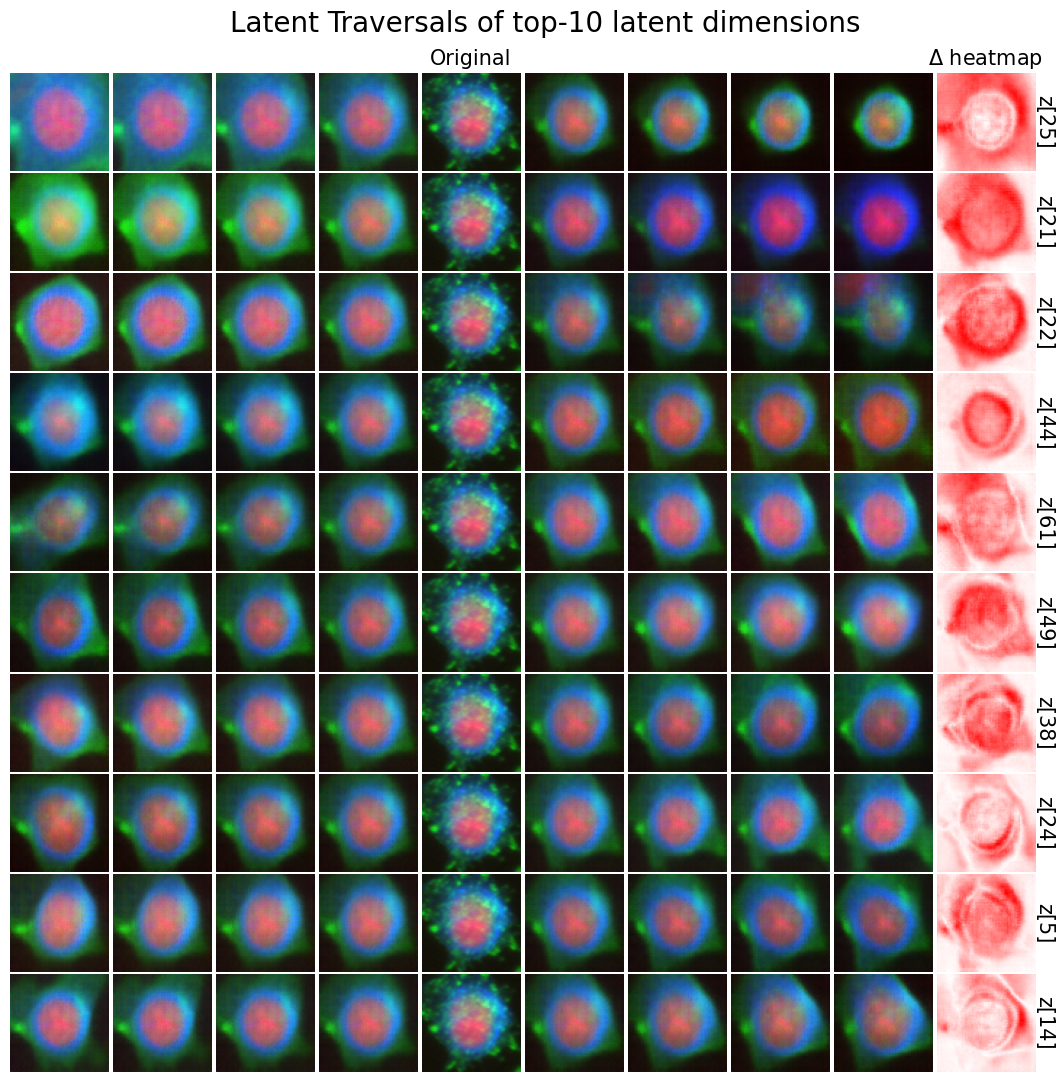

In [36]:
# --- Main execution ---
top10_dims_plus = top50_dims_plus[:topN]
idx = 200

dataset = val_loader.dataset
x, _ = dataset[idx]
x = x.unsqueeze(0).to(device)

with torch.no_grad():
    mu, logvar = model_plus.encode(x)
    z = model_plus.reparameterize(mu, logvar)

rows, diffmaps, original_recon = compute_latent_traversals_and_heatmaps(model_plus, x, z, top10_dims_plus, delta_values)

fig, axs = plt.subplots(topN, steps + 1, figsize=(11, 11))

for i in range(topN):
    for j in range(steps):
        img = rows[i][j].permute(1, 2, 0).numpy()
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
    axs[i, steps // 2].imshow(x[0].permute(1, 2, 0).cpu().numpy())
    axs[i, -1].imshow(diffmaps[i], cmap=white_red)
    # set y and x labels to nothing not axis off
    axs[i, -1].set_xticks([])
    axs[i, -1].set_yticks([])
    # remove border
    axs[i, -1].spines['top'].set_visible(False)
    axs[i, -1].spines['right'].set_visible(False)
    axs[i, -1].spines['left'].set_visible(False)
    axs[i, -1].spines['bottom'].set_visible(False)
    axs[i, -1].set_ylabel(f"z[{top10_dims_plus[i]}]", rotation=270, labelpad=-70, fontsize=15)

axs[0, steps // 2].set_title("Original", fontsize=15)
axs[0, -1].set_title(r"$\Delta$ heatmap", fontsize=15)

fig.suptitle("Latent Traversals of top-10 latent dimensions", fontsize=20)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.005)
plt.show()

In [8]:
def compute_latent_effect_heatmap_per_channel(model, x, mu, z_idx, delta_range=(-3, 3), steps=5):
    """
    Compute per-channel average heatmap of latent dim z_idx on CPU to avoid GPU OOM.
    """
    base_recon = model.decode(mu).detach().cpu()  # move to CPU
    delta_vals = torch.linspace(*delta_range, steps).cpu()
    diffs = []

    for delta in delta_vals:
        z_ = mu.clone()
        z_[:, z_idx] += delta.to(mu.device)
        recon = model.decode(z_).detach().cpu()
        diff = torch.abs(recon - base_recon)[0]  # [3, H, W] on CPU
        diffs.append(diff)

        # Free memory
        del recon, z_, delta
        torch.cuda.empty_cache()

    stacked = torch.stack(diffs)  # [steps, 3, H, W]
    mean_diff = stacked.mean(dim=0)  # [3, H, W]

    heatmap = {
        'mixed': mean_diff.sum(dim=0),  # [H, W]
        'R': mean_diff[0],
        'G': mean_diff[1],
        'B': mean_diff[2]
    }
    return heatmap

In [9]:
import torch
@torch.no_grad()
def compute_avg_latent_heatmaps_by_channel(model, loader, top_dims, n_samples=100, steps=5):
    model.eval()
    device = next(model.parameters()).device
    H, W = 68, 68  # adjust if needed
    heatmaps = {
        'mixed': [torch.zeros(H, W) for _ in top_dims],
        'R':     [torch.zeros(H, W) for _ in top_dims],
        'G':     [torch.zeros(H, W) for _ in top_dims],
        'B':     [torch.zeros(H, W) for _ in top_dims]
    }
    count = 0

    for x_batch, _ in loader:
        x_batch = x_batch.to(device)
        mu, _ = model.encode(x_batch)

        for b in range(min(x_batch.size(0), n_samples - count)):
            x = x_batch[b:b+1]
            mu_i = mu[b:b+1]

            for i, z_idx in enumerate(top_dims):
                h = compute_latent_effect_heatmap_per_channel(model, x, mu_i, z_idx, steps=steps)
                for k in heatmaps:
                    heatmaps[k][i] += h[k]

                # Free memory
                del h
                torch.cuda.empty_cache()

            count += 1
            if count >= n_samples:
                break
        if count >= n_samples:
            break

    return {k: [h / count for h in v] for k, v in heatmaps.items()}

In [23]:
# white black
from matplotlib.colors import LinearSegmentedColormap
white_black = LinearSegmentedColormap.from_list("white_black", ["white", "black"])
# white red
white_red = LinearSegmentedColormap.from_list("white_red", ["white", "red"])
# white blue
white_blue = LinearSegmentedColormap.from_list("white_blue", ["white", "blue"])
# white green
white_green = LinearSegmentedColormap.from_list("white_green", ["white", "green"])


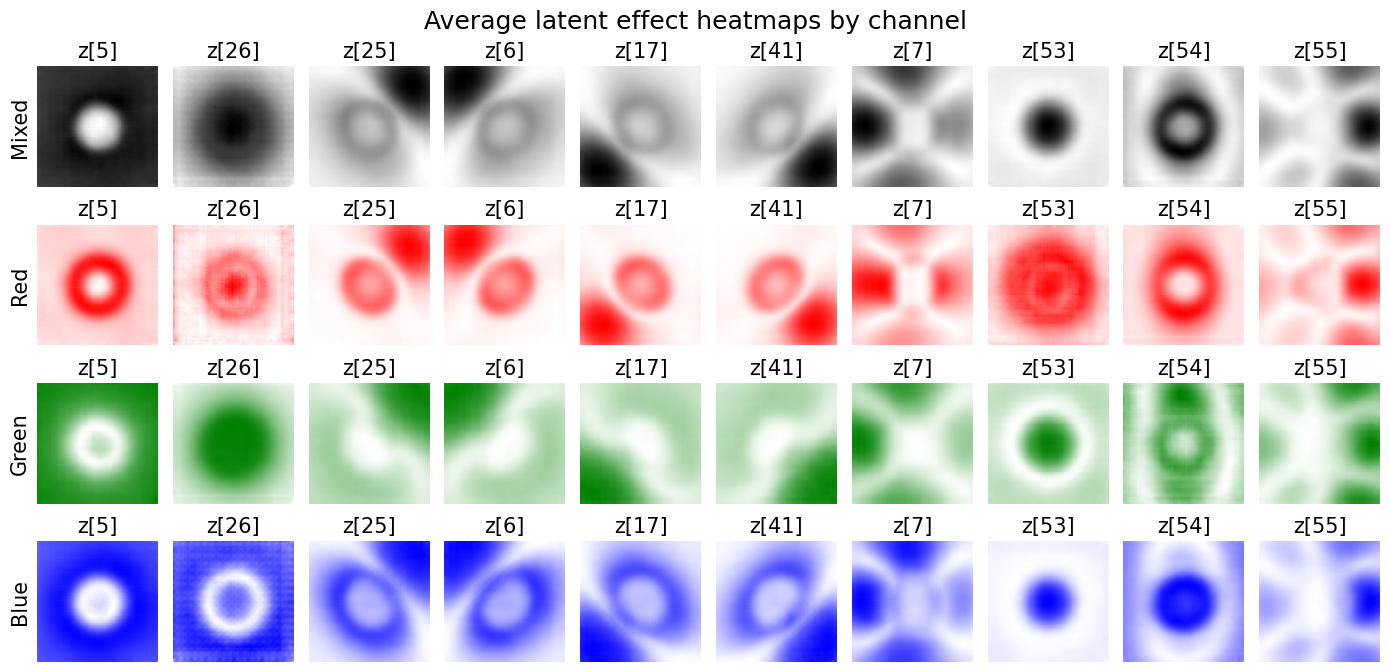

In [37]:
# Compute for top-10 dims
top10_dims = top50_dims_large[:10]
avg_heatmaps = compute_avg_latent_heatmaps_by_channel(model_large, val_loader, top10_dims, n_samples=500, steps=5)

# Plot: 8x10 grid for Mixed / R / G / B
fig, axs = plt.subplots(4, 10, figsize=(14, 7))
channels = ['mixed', 'R', 'G', 'B']
titles = ['Mixed', 'Red', 'Green', 'Blue']

cmaps = {
    'mixed': white_black,
    'R': white_red,
    'G': white_green,
    'B': white_blue
}

for row in range(4):
    for col in range(10):
        i = row * 10 + col
        group = i // 10     # 0: mixed, 1: R, 2: G, 3: B
        idx = i % 10
        ax = axs[row, col]
        if idx < len(avg_heatmaps[channels[group]]):
            hm = avg_heatmaps[channels[group]][idx].numpy()
            im = ax.imshow(hm, cmap=cmaps[channels[group]])
            ax.set_title(f"z[{top10_dims[idx]}]", fontsize=15)
        # dont do axis off
        ax.set_xticks([])
        ax.set_yticks([])
        # remove border
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

# add y label at the left side
axs[0, 0].set_ylabel("Mixed", fontsize=15, rotation=90, labelpad=5)
axs[1, 0].set_ylabel("Red", fontsize=15, rotation=90, labelpad=5)
axs[2, 0].set_ylabel("Green", fontsize=15, rotation=90, labelpad=5)
axs[3, 0].set_ylabel("Blue", fontsize=15, rotation=90, labelpad=5)

fig.suptitle("Average latent effect heatmaps by channel", fontsize=18, y=0.97)
plt.tight_layout()
plt.show()

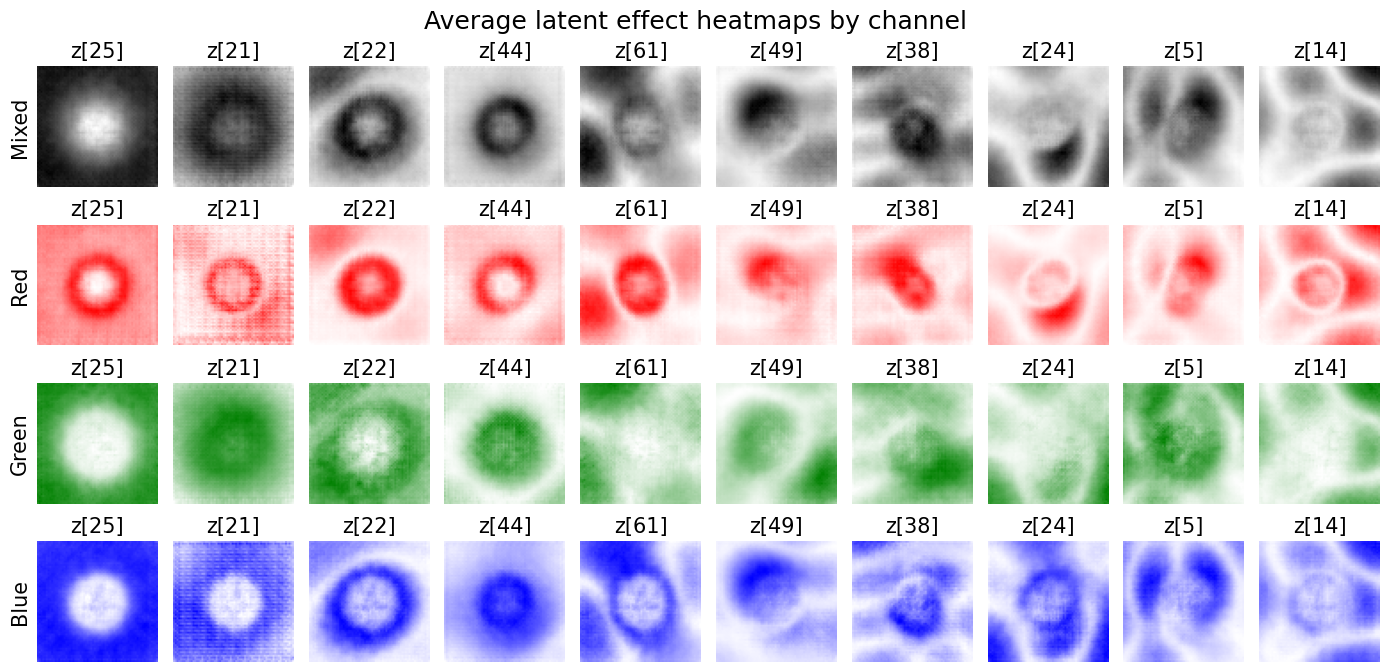

In [36]:
# Compute for top-10 dims
top10_dims = top50_dims_plus[:10]
avg_heatmaps = compute_avg_latent_heatmaps_by_channel(model_plus, val_loader, top10_dims, n_samples=500, steps=5)

# Plot: 8x10 grid for Mixed / R / G / B
fig, axs = plt.subplots(4, 10, figsize=(14, 7))
channels = ['mixed', 'R', 'G', 'B']
titles = ['Mixed', 'Red', 'Green', 'Blue']

cmaps = {
    'mixed': white_black,
    'R': white_red,
    'G': white_green,
    'B': white_blue
}

for row in range(4):
    for col in range(10):
        i = row * 10 + col
        group = i // 10     # 0: mixed, 1: R, 2: G, 3: B
        idx = i % 10
        ax = axs[row, col]
        if idx < len(avg_heatmaps[channels[group]]):
            hm = avg_heatmaps[channels[group]][idx].numpy()
            im = ax.imshow(hm, cmap=cmaps[channels[group]])
            ax.set_title(f"z[{top10_dims[idx]}]", fontsize=15)
        # dont do axis off
        ax.set_xticks([])
        ax.set_yticks([])
        # remove border
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

# add y label at the left side
axs[0, 0].set_ylabel("Mixed", fontsize=15, rotation=90, labelpad=5)
axs[1, 0].set_ylabel("Red", fontsize=15, rotation=90, labelpad=5)
axs[2, 0].set_ylabel("Green", fontsize=15, rotation=90, labelpad=5)
axs[3, 0].set_ylabel("Blue", fontsize=15, rotation=90, labelpad=5)

fig.suptitle("Average latent effect heatmaps by channel", fontsize=18, y=0.97)
plt.tight_layout()
plt.show()